# T51 — Afro-Arabia thermochronology on paleo-Earth: continent-scale Phanerozoic exhumation

**Cluster F: paleo-geography and paleo-topography.**

*Based on:* Boone, S.C. et al. (2025), *Scientific Data* 12:472. *Phanerozoic thermochronology record of Afro-Arabia through space and time* — the EarthBank-hosted Afro-Arabian Rift System (AARS) low-temperature thermochronology compilation: **7,275 analyses + 668 digitised thermal-history models** covering East/North/South Africa, Arabia, the Red Sea, the Gulf of Aden, and the East African Rift System.

## What this notebook does

Extends the T47 → T48 → T49 → T50 ThermoPlates workflow from Central Asia to the **Afro-Arabian continent** — a passive-margin / rift-dominated system with active convergence only along its northern (Tethyan + Bitlis-Zagros + Cyprus) margins. The dataset is **14× larger** than ThermoPlates Central Asia and spans the entire Phanerozoic.

Following Boone et al. (2025) and the user instruction for this tutorial, the analysis focuses on **convergence rate** as the candidate tectonic driver rather than dynamic topography — dynamic topography is generally less relevant for Afro-Arabia (mostly passive margins, rift initiation, intra-plate uplift) and is delegated to *Extend this* as a user exercise pointing at T48 as the template.

**Sections:**
1. **§1** Load plate model + AARS thermochronology compilation.
2. **§2** Per-sample cooling rate at the snapshot age (Boone's `TempDiff` column).
3. **§3** Layer A — cooling rates × seafloor age (global orthographic centred on Africa).
4. **§4** Layer B — cooling rates × paleotopography (regional zoom).
5. **§5** Layer C — cooling rates × convergence rate (subduction-zone segments on the Tethyan + Cyprus + Bitlis-Zagros margins).
6. **§6** Cross-variable correlations — cooling rate vs convergence rate, Pearson r per age, time-series.

**Audience**: postgrad → researcher.
**Difficulty**: ★★★.
**Runtime**: ~3 min for a single snapshot; ~10 min for the time-series cross-variable sweep at 5-Myr cadence.

## Data availability

**Boone, S.C. et al. (2025)** — *Phanerozoic thermochronology record of Afro-Arabia through space and time*, *Scientific Data* 12, 472. https://doi.org/10.1038/s41597-025-04767-6 ([open-access CC-BY 4.0]).

Dataset DOI on EarthBank (the platform Boone et al. 2025 publishes on): https://doi.org/10.58024/AGUM97FC4439 (Boone et al. 2024).

### Bundled subset

This notebook expects a CSV at `data/thermochronology_afro_arabia/afro_arabia_thermal_histories.csv` with the same column convention as the ThermoPlates Central Asia compilation (the two share Sam Boone as lead author + the same EarthBank platform):

```
lat, lon, sample_name, TOAGE, FROMAGE, OnlyCooling, TempDiff, Region [, Sub-Region]
```

where `TempDiff` (°C/Myr) is Boone's pre-computed per-sample, per-window cooling rate (used directly — do NOT recompute from `OnlyCooling`; see T47 / T48 / T50 for the OnlyCooling pitfall).

### To populate the data dir on first run

1. Register at the EarthBank platform: https://ausgeochem.auscope.org.au
2. Navigate to the Boone et al. 2024 Afro-Arabian compilation (DOI 10.58024/AGUM97FC4439).
3. Export to CSV with the columns above; drop into `data/thermochronology_afro_arabia/`.

Until the CSV is in place, this notebook fails fast on cell 1 of §1 with a clear `FileNotFoundError` naming the expected path.

## Source

- Upstream paper: Boone et al. 2025 Sci. Data — https://doi.org/10.1038/s41597-025-04767-6
- Sibling notebook for the methodology: T47 (Central Asia ThermoPlates workflow).

## Environment + imports

In [1]:
from pathlib import Path
import os, sys, warnings
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

import gplately
import pygmt
from plate_model_manager import PlateModelManager

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, pd, xr, gplately, pygmt):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', 'n/a')}")

Environment
  python      3.12.5
  numpy       2.3.2
  pandas      2.2.3
  xarray      2026.4.0
  gplately    2.0.0.post19+git.2cce7bb3
  pygmt       v0.18.0


In [2]:
# === USER CONFIGURATION =====================================================
# Plate model + reference frame. Z22 mantle frame — matches T47 / T48-T50
# (passive-margin + rift + mantle-flow context, no paleoclimate-vs-paleomag
# comparison is being drawn here).
MODEL_NAME             = "Zahirovic2022"
ANCHOR_PLATE_ID        = 0

# Headline snapshot age (Ma). 25 Ma is the late Oligocene — captures the
# AARS tectonic transition: incipient Red Sea opening, EARS initiation,
# Atlas Mts uplift acceleration, Bitlis-Zagros collision onset.
RECONSTRUCTION_TIME    = 150.0

# Inputs.
HISTORIES_CSV          = Path("data/thermochronology_afro_arabia/afro_arabia_thermal_histories.csv")
# PaleoDEM directory — geochemistry-corrected Scotese & Wright 2018 (Zhou,
# Müller, Farahbakhsh, in review). The bundled subset only carries 6 ages
# (50/100/200/300/400/500 Ma); the full 5-Myr cadence (0-540 Ma, 109 NCs)
# lives in the Paleotopo_data_assimilation repository. Resolved at notebook
# runtime by trying these in order:
PALEODEM_DIR_CANDIDATES = [
    Path("data/paleotopo_scotese/corrected_SW"),     # bundled with the repo — 16 ages (25/50-Myr cadence)
    Path("external/Paleotopo_data_assimilation/data/corrected_Scotese"),
    Path.home() / "Documents/Software/Paleotopo_data_assimilation/data/corrected_Scotese",
]
PALEODEM_DIR           = next((p for p in PALEODEM_DIR_CANDIDATES if p.exists()),
                              PALEODEM_DIR_CANDIDATES[0])
print(f"  PaleoDEM dir resolved to: {PALEODEM_DIR} "
      f"({len(list(PALEODEM_DIR.glob('*_corrected_SW.nc')))} corrected_SW NCs available)")

# Boone's cooling-rate classification thresholds (°C/Myr) — same as Central Asia.
FAST_CR                = 0.5      # `fast`
VERY_FAST_CR           = 1.0      # `very fast`
EXTRA_FAST_CR          = 1.5      # `extra fast`

# Cooling-rate colour-scale range — viridis 0–3 °C/Myr (matches T48/T49/T50 convention).
COOLING_CPT_RANGE      = (0.0, 3.0)

# Region for the Afro-Arabia regional zoom.
REGION_AFRO_ARABIA     = [-25, 65, -40, 45]   # [W, E, S, N]
GLOBAL_PROJ            = "G20/10/16c"          # orthographic centred 20°E 10°N
REGIONAL_PROJ          = "B22/2/-25/30/18c"     # Albers conic, centre 22°E 2°N, secants -25°/30°

# Subduction-kinematics tessellation density (radians along trench).
# 0.005 rad ~ 32 km segments — fine enough for continental-scale analysis.
TESS_THRESHOLD_RAD     = 0.005

# Age sweep for the §6 cross-variable time-series.
AGE_MIN_MA             = 0
AGE_MAX_MA             = 230      # Boone et al. (2025) Sci. Data Phanerozoic coverage
AGE_STEP_MA            = 5        # 47 snapshots
AGES_MA                = list(range(AGE_MIN_MA, AGE_MAX_MA + 1, AGE_STEP_MA))

# Output paths for downstream joins.
MASTER_PARQUET_DIR     = Path("data/thermochronology_afro_arabia/thermochron_master")
MASTER_PARQUET_DIR.mkdir(parents=True, exist_ok=True)
KIN_MASTER_DIR         = Path("data/thermochronology_afro_arabia/kinematics_master")
KIN_MASTER_DIR.mkdir(parents=True, exist_ok=True)
# ============================================================================

  PaleoDEM dir resolved to: data/paleotopo_scotese/corrected_SW (16 corrected_SW NCs available)


## 1. Load plate model + AARS thermochronology compilation

In [3]:
pmm = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
    anchor_plate_id=ANCHOR_PLATE_ID,
)
gplot = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_coastlines(),
    continents=model.get_continental_polygons(),
    COBs=model.get_COBs(),
    time=float(RECONSTRUCTION_TIME),
    plot_engine=gplately.PygmtPlotEngine(),
)


def build_afro_arabia_csv_from_earthbank(earthbank_dir: Path, out_csv: Path,
                                          grid_step_myr: int = 5,
                                          path_type: str = "Best fit") -> int:
    """Flatten the Boone et al. (2025) EarthBank Afro-Arabia export
    (multi-sheet Excel) into the same flat-CSV schema as ThermoPlates
    Central Asia.

    Reads Samples.xlsx (lat/lon per sample) + Thermal History.xlsx
    (per-sample t-T paths). For each sample with a Best-fit path,
    interpolates the t-T points onto a regular `grid_step_myr` grid
    (0 → max age) and emits one row per window with the per-window
    cooling rate as `TempDiff` (°C/Myr, positive when the rock cools
    going from older to younger time).

    Returns number of (sample, window) rows written."""
    import openpyxl, warnings, collections
    warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

    # 1. Samples → {sampleName: (lat, lon)}
    wb = openpyxl.load_workbook(earthbank_dir / "Samples" / "Samples.xlsx", read_only=True)
    ws = wb["Samples"]
    hdr = [c.value for c in next(ws.iter_rows(min_row=1, max_row=1))]
    ci = {h: i for i, h in enumerate(hdr)}
    samples = {}
    for r in ws.iter_rows(min_row=2, values_only=True):
        sn = r[ci["sampleName"]]
        if sn and r[ci["latitude"]] is not None and r[ci["longitude"]] is not None:
            samples[sn] = (float(r[ci["latitude"]]), float(r[ci["longitude"]]))
    wb.close()

    # 2. Thermal History — datapointName → sampleName  AND  paths
    wb = openpyxl.load_workbook(earthbank_dir / "Thermal History" / "Thermal History.xlsx",
                                 read_only=True)
    ws = wb["tT Sample"]
    hdr = [c.value for c in next(ws.iter_rows(min_row=1, max_row=1))]
    ci2 = {h: i for i, h in enumerate(hdr)}
    dp_to_sample = {}
    for r in ws.iter_rows(min_row=2, values_only=True):
        dp = r[ci2["datapointName"]]
        if dp:
            dp_to_sample[dp] = r[ci2["sample"]] or r[ci2["name"]]

    ws = wb["tT Path"]
    hdr = [c.value for c in next(ws.iter_rows(min_row=1, max_row=1))]
    ci3 = {h: i for i, h in enumerate(hdr)}
    paths = collections.defaultdict(list)
    for r in ws.iter_rows(min_row=2, values_only=True):
        if r[ci3["pathType"]] != path_type: continue
        paths[r[ci3["datapointName"]]].append(
            (float(r[ci3["modelTime"]]), float(r[ci3["modelTemp"]])))
    wb.close()

    # 3. For each datapoint, interpolate to regular grid + compute per-window rate
    out_rows = []
    for dp, pts in paths.items():
        sname = dp_to_sample.get(dp)
        if not sname: continue
        latlon = samples.get(sname)
        if not latlon: continue
        lat, lon = latlon
        pts = sorted(pts)
        ts, Ts = zip(*pts)
        if ts[-1] - ts[0] < grid_step_myr: continue
        grid = np.arange(0, int(ts[-1]) + 1, grid_step_myr).astype(float)
        T_grid = np.interp(grid, ts, Ts)
        # window i: TOAGE = grid[i] (younger), FROMAGE = grid[i+1] (older)
        for i in range(len(grid) - 1):
            toage   = float(grid[i])
            fromage = float(grid[i + 1])
            dT      = float(T_grid[i + 1] - T_grid[i])     # T_older - T_younger (>0 if cooled)
            dur     = fromage - toage
            tempdiff = dT / dur if dur > 0 else np.nan
            out_rows.append({
                "lat": lat, "lon": lon, "sample_name": sname,
                "TOAGE": toage, "FROMAGE": fromage,
                "OnlyCooling": dT, "TempDiff": tempdiff,
            })
    out_df = pd.DataFrame(out_rows)
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    out_df.to_csv(out_csv, index=False)
    return len(out_df)


# Auto-build the flat CSV from the EarthBank export if not already present
EARTHBANK_DIR = HISTORIES_CSV.parent / "Phanerozoic thermochronology record of Afro-Arabia through space and time"
if not HISTORIES_CSV.exists():
    if EARTHBANK_DIR.exists():
        n = build_afro_arabia_csv_from_earthbank(EARTHBANK_DIR, HISTORIES_CSV)
        print(f"  ✓ flattened EarthBank export → {HISTORIES_CSV.name} "
              f"({n:,} (sample, window) rows)")
    else:
        raise FileNotFoundError(
            f"Neither flat CSV nor EarthBank export found at {HISTORIES_CSV.parent}.\n"
            f"Download Boone et al. (2024) Afro-Arabia compilation from EarthBank "
            f"(DOI 10.58024/AGUM97FC4439) and drop the export folder at\n"
            f"  {EARTHBANK_DIR}\n"
            f"OR drop a pre-flattened CSV at\n"
            f"  {HISTORIES_CSV}\n"
            f"See this notebook's Data availability cell."
        )

hist = pd.read_csv(HISTORIES_CSV, comment="#")
print(f"  Afro-Arabian Rift System (AARS) thermal histories: {len(hist):,} rows, {hist['sample_name'].nunique()} unique samples")
print(f"  age coverage: {hist['TOAGE'].min():.0f} – {hist['FROMAGE'].max():.0f} Ma")
print(f"  lat coverage: {hist['lat'].min():.1f}° – {hist['lat'].max():.1f}°")
print(f"  lon coverage: {hist['lon'].min():.1f}° – {hist['lon'].max():.1f}°")

  Afro-Arabian Rift System (AARS) thermal histories: 21,859 rows, 425 unique samples
  age coverage: 0 – 600 Ma
  lat coverage: -24.6° – 29.7°
  lon coverage: 28.2° – 58.8°


## 2. Per-sample cooling rate at the snapshot age

Uses Boone's pre-computed `TempDiff` column directly. **Do not** recompute from
`OnlyCooling / (FROMAGE - TOAGE)` — `OnlyCooling` is the cumulative cooling-only
envelope, not the per-window rate, and dividing it by the interval duration
gives values roughly two orders of magnitude too large (see T47/T48/T50).

In [4]:
def per_sample_cooling_at(age_ma: float, hist_df: pd.DataFrame) -> pd.DataFrame:
    """One row per sample with the cooling rate (°C/Myr) at `age_ma`."""
    snap = hist_df.loc[hist_df["TOAGE"] == int(age_ma)].copy()
    snap["cooling_rate"] = pd.to_numeric(snap["TempDiff"], errors="coerce")
    snap = snap.dropna(subset=["cooling_rate", "lat", "lon"]).copy()
    snap["cooling_rate"] = snap["cooling_rate"].clip(lower=0)
    return (snap.groupby("sample_name", as_index=False)
                .agg(lat=("lat", "first"), lon=("lon", "first"),
                     cooling_rate=("cooling_rate", "mean")))

samples_now = per_sample_cooling_at(RECONSTRUCTION_TIME, hist)
print(f"  {len(samples_now)} samples bracket {RECONSTRUCTION_TIME:.0f} Ma; "
      f"cooling-rate range {samples_now.cooling_rate.min():.2f} – "
      f"{samples_now.cooling_rate.max():.2f} °C/Myr")

# Reconstruct samples to paleo-position (mantle frame, ANCHOR_PLATE_ID=0)
gpts = gplately.Points(recon,
                        samples_now["lon"].to_numpy(float),
                        samples_now["lat"].to_numpy(float),
                        anchor_plate_id=ANCHOR_PLATE_ID)
rlons, rlats = gpts.reconstruct(RECONSTRUCTION_TIME,
                                 return_array=True,
                                 anchor_plate_id=ANCHOR_PLATE_ID)
samples_now = samples_now.assign(rlon=rlons, rlat=rlats).dropna(subset=["rlon","rlat"]).copy()
print(f"  reconstructed {len(samples_now)} samples to {RECONSTRUCTION_TIME:.0f} Ma")

  245 samples bracket 150 Ma; cooling-rate range 0.00 – 4.74 °C/Myr
  reconstructed 245 samples to 150 Ma


## 3. Layer A — cooling rates × seafloor age (global orthographic centred on Africa)

Same pattern as T48 §5: Z22 age grid as the basemap, thin-black plate-boundary
backbone + styled ridges/trenches/teeth on top, then cooling-rate dots. The
orthographic view centred on (20°E, 10°N) frames the Afro-Arabia sampling area
together with its tectonic neighbours: the active Tethyan margin to the north,
the East African Rift to the east, the Red Sea / Gulf of Aden rifts arcing
north-east.

In [5]:
# Z22 age grid (fetched on first run via PMM)
agegrid_da = xr.open_dataarray(
    model.get_raster("AgeGrids", time=float(RECONSTRUCTION_TIME))
)

fig_A = pygmt.Figure()
fig_A.basemap(region="d", projection=GLOBAL_PROJ, frame=["af"])
pygmt.makecpt(cmap="data/age_2020.cpt", series=[0, 250, 1], background="o")
fig_A.grdimage(agegrid_da, cmap=True)
gplot.time = float(RECONSTRUCTION_TIME)
gplot.plot_continents(fig_A, fill="gray95", pen="0.3p,gray40")
gplot.plot_all_topological_sections(fig_A, pen="0.5p,black")    # thin BLACK backbone
gplot.plot_ridges(fig_A, pen="0.8p,red3")
gplot.plot_trenches(fig_A, pen="0.8p,black")
gplot.plot_subduction_teeth(fig_A, color="black")
fig_A.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o-5c/1c",
               frame=["xa50f10+lSeafloor age (Ma)"])
# Cooling-rate dots
pygmt.makecpt(cmap="viridis", series=[*COOLING_CPT_RANGE, 0.1], background="o")
fig_A.plot(x=samples_now["rlon"], y=samples_now["rlat"],
           fill=samples_now["cooling_rate"], cmap=True,
           style="c0.16c", pen="0.3p,black")
fig_A.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o5c/1c",
               frame=["xa0.5f0.1+lCooling rate (@.C/Myr)"])
fig_A.text(text=f"{RECONSTRUCTION_TIME:.0f} Ma  ({MODEL_NAME}) — Afro-Arabia cooling × seafloor age",
           position="TL", offset="0.25c/-0.25c", justify="TL",
           font="12p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig_A.show(width=900)

makecpt [WARNING]: data/age_2020.cpt is a discrete CPT. You can stretch it (-T<min>/<max>) but not interpolate it (-T<min>/<max>/<inc>).
makecpt [WARNING]: Selecting the given range and ignoring the increment setting.


### What this figure shows you

At 25 Ma the AARS sampling area sits well inside the African plate, far from
the active Tethyan margin (visible as the E-W band of plate boundaries running
north of the cluster). Yellow viridis dots — fast-cooling samples — concentrate
along the **incipient Red Sea + Gulf of Aden rift axis** and the **flanks of
the future Ethiopian Plateau / Afar triple junction**, recording the rift-
shoulder uplift and erosion that accompanied the initial Red Sea / Gulf of Aden
opening at ~25–20 Ma. The bulk of the African interior shows low-to-moderate
cooling rates (dark viridis) — passive Precambrian craton.

## 4. Layer B — cooling rates × paleotopography (Afro-Arabia regional zoom)

Albers conic zoom centred over the African continent. Geochemistry-corrected
Scotese & Wright (2018) paleo-DEM (reused from T33) provides the topographic
context — where the inherited relief was at 25 Ma. Cooling-rate dots are
expected to track regions of pre-existing high relief (rift-shoulder uplifts,
the Ethiopian dome) where reactivation can drive cooling pulses.

  paleotopo grid: 150Ma_corrected_SW.nc (150 Ma — nearest to 150 Ma)
2026-06-28,07:18:28 - pmm - WARNING - The layer(Coastlines) was not found in model(scotese_and_wright2018).
  cooling-rate snapshot at pt_age=150 Ma: 245 samples

grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.



  re-reconstructed 243 samples through scotese_and_wright2018 @ 150 Ma (2 dropped — outside SW static-polygon coverage)


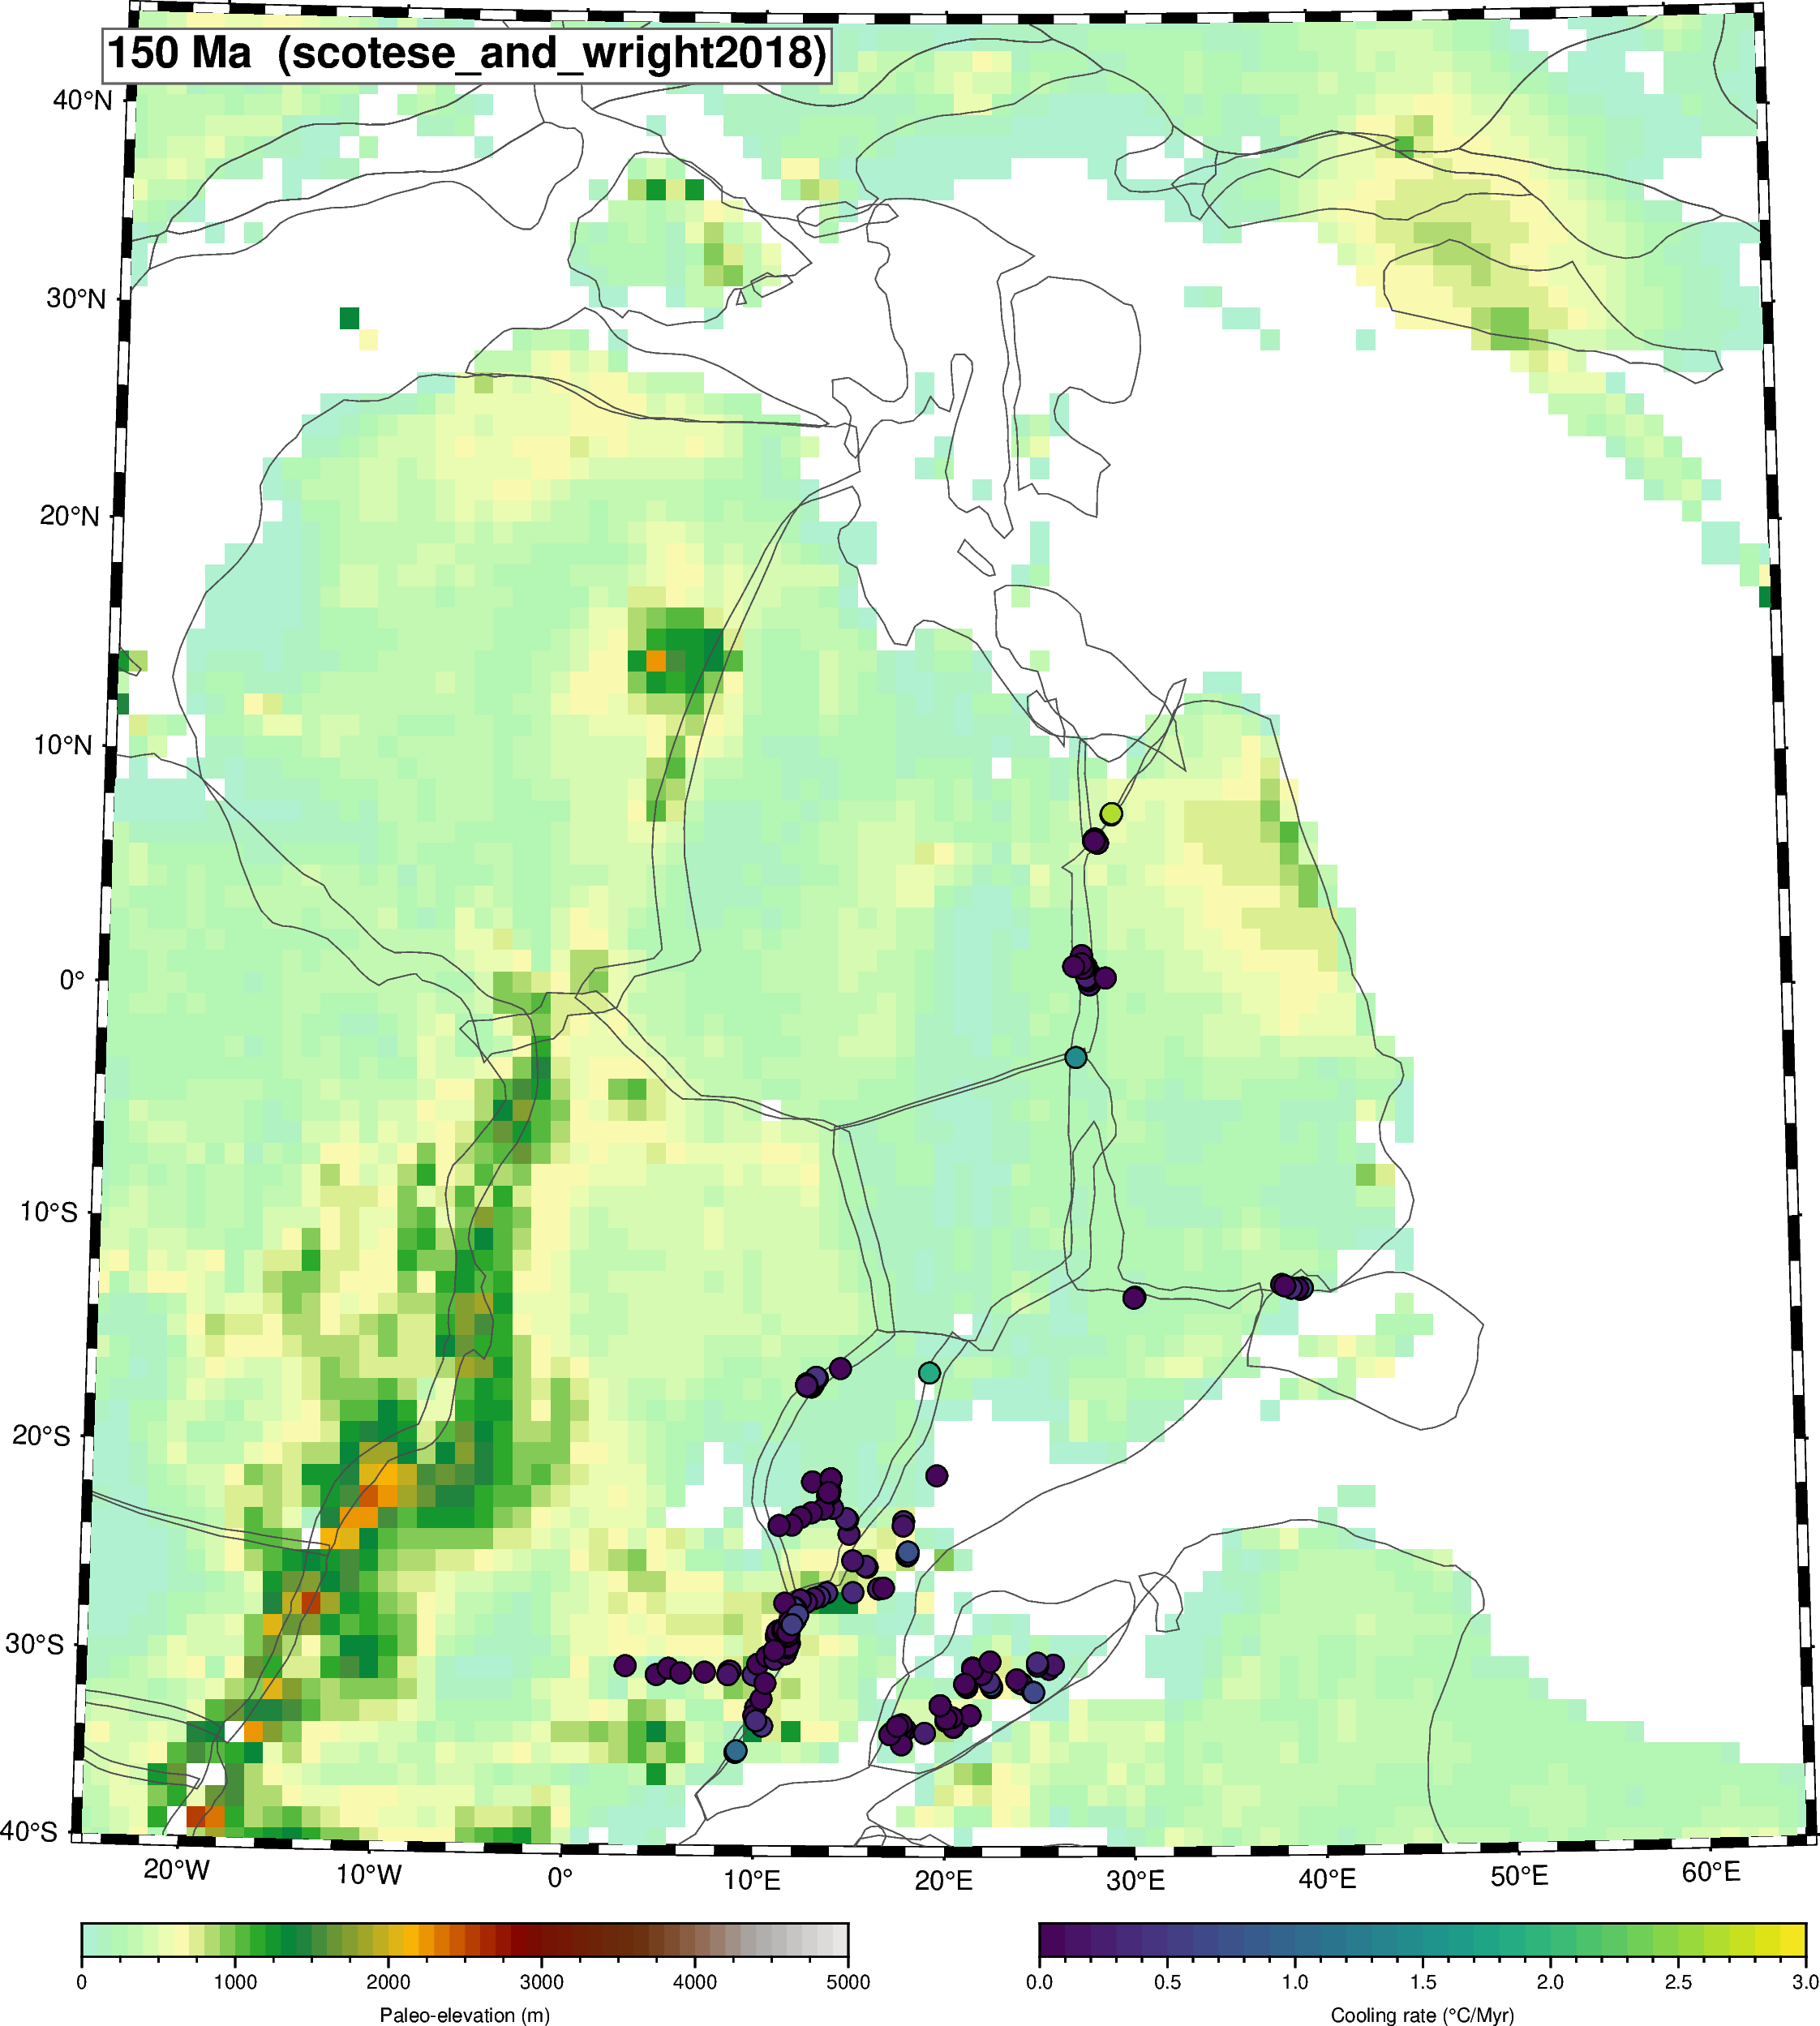

In [6]:
# Paleotopography (nearest 50-Myr step of corrected Scotese & Wright 2018)
# IMPORTANT: the corrected SW paleo-DEM is in Scotese & Wright's own plate
# frame. To overlay reconstructed samples honestly, we must reconstruct them
# with the SAME plate model that produced the DEM — NOT Z22. Mixing a
# DEM from one model with samples reconstructed via another model places
# the dots in a different absolute-position frame from the underlying grid
# (cf. CLAUDE.md: "Plate-model-match rule for any gridded data overlay").
import re as _re
paleotopo_steps = sorted(
    int(_re.search(r"^(\d+)Ma_", p.name).group(1))
    for p in PALEODEM_DIR.glob("*Ma_corrected_SW.nc")
)
pt_age = min(paleotopo_steps, key=lambda a: abs(a - RECONSTRUCTION_TIME))
pt_path = PALEODEM_DIR / f"{pt_age}Ma_corrected_SW.nc"
pt_ds = xr.open_dataset(pt_path)
pt_da = pt_ds["M_corrected"] if "M_corrected" in pt_ds.data_vars else pt_ds["z"]
pt_land = pt_da.where(pt_da >= 0)
print(f"  paleotopo grid: {pt_path.name} ({pt_age} Ma — nearest to {RECONSTRUCTION_TIME:.0f} Ma)")

# Set up a Scotese & Wright reconstruction stack (separate from the Z22
# stack used in the rest of the notebook). PMM exposes the model as
# "scotese_and_wright2018"; it sits in its own paleomag spin-axis frame
# at anchor 0 by default.
model_sw = pmm.get_model("scotese_and_wright2018", data_dir="./gplately_data")
recon_sw = gplately.PlateReconstruction(
    rotation_model=model_sw.get_rotation_model(),
    topology_features=model_sw.get_topologies() if hasattr(model_sw, "get_topologies") else None,
    static_polygons=model_sw.get_static_polygons(),
    anchor_plate_id=0,
)
try:
    coastlines_sw = model_sw.get_coastlines()
except Exception:
    coastlines_sw = None
gplot_sw = gplately.PlotTopologies(
    plate_reconstruction=recon_sw,
    coastlines=coastlines_sw,
    continents=model_sw.get_continental_polygons(),
    COBs=None,
    time=float(RECONSTRUCTION_TIME),
    plot_engine=gplately.PygmtPlotEngine(),
)

# The Scotese & Wright DEMs come at 50-Myr cadence, so pt_age may differ
# from RECONSTRUCTION_TIME. To keep the whole Layer-B panel self-consistent
# (samples + DEM in the same plate-model frame AT THE SAME AGE), recompute
# the per-sample cooling rate AT pt_age and re-reconstruct the sample lon/lat
# AT pt_age through the SW rotation model.
samples_sw_base = per_sample_cooling_at(pt_age, hist)
print(f"  cooling-rate snapshot at pt_age={pt_age} Ma: {len(samples_sw_base)} samples")

# Loop per-sample (batched Points.reconstruct silently drops points outside
# SW static-polygon coverage, breaking the row-to-row correspondence).
rlons_sw = np.full(len(samples_sw_base), np.nan)
rlats_sw = np.full(len(samples_sw_base), np.nan)
for i, (lon, lat) in enumerate(zip(samples_sw_base["lon"].to_numpy(float),
                                     samples_sw_base["lat"].to_numpy(float))):
    try:
        gpt = gplately.Points(recon_sw, [lon], [lat], anchor_plate_id=0)
        rl, rla = gpt.reconstruct(float(pt_age),
                                   return_array=True, anchor_plate_id=0)
        if len(rl) == 1 and np.isfinite(rl[0]) and np.isfinite(rla[0]):
            rlons_sw[i] = float(rl[0])
            rlats_sw[i] = float(rla[0])
    except Exception:
        pass   # leave as NaN
samples_sw = samples_sw_base[["sample_name", "cooling_rate"]].copy()
samples_sw["rlon_sw"] = rlons_sw
samples_sw["rlat_sw"] = rlats_sw
n_dropped = int(samples_sw[["rlon_sw","rlat_sw"]].isna().any(axis=1).sum())
samples_sw = samples_sw.dropna(subset=["rlon_sw", "rlat_sw"])
print(f"  re-reconstructed {len(samples_sw)} samples through scotese_and_wright2018 @ {pt_age} Ma"
      f" ({n_dropped} dropped — outside SW static-polygon coverage)")
gplot_sw.time = float(pt_age)   # match the gplot helper\'s age too

fig_B = pygmt.Figure()
fig_B.basemap(region=REGION_AFRO_ARABIA, projection=REGIONAL_PROJ, frame=["af", "WSne"])
pygmt.makecpt(cmap="dem4", series=[0, 5000, 100], background="o")
fig_B.grdimage(pt_land, cmap=True, nan_transparent=True)
gplot_sw.plot_continents(fig_B, fill=None, pen="0.3p,gray30")
# SW model has no plate-boundary topologies; the continent outlines provide
# the geographic anchor.
fig_B.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o-5c/0.8c",
               frame=["xa1000f250+lPaleo-elevation (m)"])
pygmt.makecpt(cmap="viridis", series=[*COOLING_CPT_RANGE, 0.1], background="o")
fig_B.plot(x=samples_sw["rlon_sw"], y=samples_sw["rlat_sw"],
           fill=samples_sw["cooling_rate"], cmap=True,
           style="c0.22c", pen="0.5p,black")
fig_B.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o5c/0.8c",
               frame=["xa0.5f0.1+lCooling rate (@.C/Myr)"])
fig_B.text(text=f"{pt_age:.0f} Ma  (scotese_and_wright2018)",
           position="TL", offset="0.25c/-0.25c", justify="TL",
           font="13p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig_B.show(width=900)

### What this figure shows you

Layer B is rendered at the SW PaleoDEM's nearest cadence step to your
configured snapshot age (50-Myr cadence — so e.g. if `RECONSTRUCTION_TIME`
is 25 Ma the panel shows 50 Ma; if 100 Ma, it's exact; if 75 Ma, it
shows 100 Ma). The whole panel is in scotese\_and\_wright2018's plate
frame at *that* age — sample cooling rates are recomputed at the DEM's
age, sample positions are reconstructed through SW to the DEM's age, and
no Z22 quantities appear.

What you see: the corrected Scotese & Wright paleo-DEM shows the inherited
African relief — the Ethiopian dome, the East African plateaus, the Atlas
Mts (NW), and the Arabian Peninsula's western escarpment all visible. The
fastest-cooling samples (bright viridis) sit along the **margins of those
elevated regions** — consistent with Boone et al. (2025)'s reading of AARS
cooling as primarily driven by post-rift escarpment retreat + rift-flank
uplift on a substrate of inherited Phanerozoic relief.

## 5. Cooling rates × dynamic-topography uplift rate

Convergence rate — the kinematic predictor used in the analogous Central Asia and Andes notebooks (T47, T52) — is **not the right context for the Afro-Arabian Rift System (AARS)**. There is no active subduction zone within ~5000 km of any AARS sample; the region's exhumation is dominantly **plume-driven** (the Afar plume head + the broader African superplume). The relevant kinematic context is therefore not horizontal plate motion but **vertical motion of the surface driven by mantle flow**, captured directly by the Young et al. (2022) **`gld428`** dynamic-topography model.

We use the **plate-frame** `gld428` grids at 5-Myr cadence (0–250 Ma coverage) and compute the **dynamic-topography uplift rate** as

$$\dot{z}_{\text{dyntopo}}(t) = \frac{DT_{\text{plate}}(t) - DT_{\text{plate}}(t + 5\,\text{Myr})}{5\,\text{Myr}}\quad [\text{m/Myr}]$$

Positive values indicate the mantle was lifting the surface over the preceding 5 Myr; negative values indicate dynamic subsidence. **The differencing is done in the plate frame** — where a point on the plate has a fixed (lat, lon) regardless of time — and then the resulting Δz field is rotated to the M21 NNR mantle frame at age `t` for paleo-geographic display. Differencing in the mantle frame (where the same lat/lon corresponds to *different* plate-points at different times) would conflate true mantle uplift with the plate-motion-through-DT-field signal and is forbidden by the suite's plate-model-match conventions (see CLAUDE.md).

### Plume-suppression caveat for `gld428`

The Young et al. (2022) `gld428` geodynamic model **does not include thermal plumes** — its boundary conditions and initial conditions suppress them, so the simulation captures only the **long-term dynamic-topography signal driven by subduction zones and the broad mantle counterflow they induce**. Active plume heads — the Afar / East-African plume in particular, which dominated the post-50 Ma history of the AARS — are NOT represented. For this reason we restrict the dynamic-topography analysis below to **ages ≥ 50 Ma**: the older Mesozoic interval is where `gld428` is informative for AARS sample interpretation. Post-50 Ma plume-driven uplift requires a different geodynamic substrate (mantle-flow models with imposed plume sources, e.g. the Flament et al. family) and is left for an "Extend this" exercise.

In [7]:
# === USER CONFIGURATION — §5/§6/§7 (dyntopo additions) ==================
# Snapshot ages for the multi-panel figure (Cenozoic + Mesozoic; covered by
# gld428 5-Myr cadence 0-250 Ma). Six well-spaced ages → 2×3 panel grid.
DYNTOPO_SNAPSHOT_AGES = [50, 100, 150, 200]    # post-50 Ma omitted (see §5 disclaimer below)
# Step (Myr) for the uplift-rate difference. Must match gld428 cadence (5).
DYNTOPO_STEP_MYR      = 5
# ±50 m/Myr cpt range for the uplift-rate basemap (matches T23).
UPLIFT_RANGE_M_PER_MYR = (-50, 50, 2)

# Plate model for sample reconstruction in §5/§6/§7. Young et al. (2022)
# ran their geodynamic simulation in the M21 NNR (Merdith 2021 no-net-rotation)
# frame — so per the plate-model-match rule we set up a separate stack here.
# The Z22 stack used in §1-§4 stays untouched.
M21NNR_DIR            = Path("data/young2022_dyntopo/M21NNR")

# Young 2022 gld428 PLATE-FRAME 5-Myr cadence grids. Filename pattern is
# "<age>.00.nc" (e.g. 0.00.nc, 5.00.nc, ..., 250.00.nc).
#
# IMPORTANT: per the no-mantle-frame-differencing rule (see CLAUDE.md),
# Δz uplift rates MUST be computed in the plate frame, then rotated to
# the mantle/paleomag frame for display. Differencing mantle-frame grids
# would conflate true uplift with the plate-motion-through-DT-field signal
# and give physically meaningless results.
GLD428_DIR_CANDIDATES = [
    Path("data/Young2022_gld428_PlateFrame"),
    Path("external/Young2022_gld428_PlateFrame"),
    Path.home() / "Documents/GPlates/GPlately-pyGMT_tutorials/data/Young2022_gld428_PlateFrame",
]
GLD428_DIR = next((p for p in GLD428_DIR_CANDIDATES if p.exists()),
                  GLD428_DIR_CANDIDATES[0])
print(f"  gld428 PLATE-frame dir: {GLD428_DIR}")
print(f"    NCs available: {len(list(GLD428_DIR.glob('*.nc')))}")
print(f"  M21 NNR plate-model dir: {M21NNR_DIR}")

# === M21 NNR PlateReconstruction (separate from the Z22 stack in §1-§4) ===
import pygplates as _pgp
m21_rot_files  = sorted(M21NNR_DIR.glob("*.rot"))
m21_all_gpml   = sorted(M21NNR_DIR.glob("*.gpml"))
# Topology features = all .gpml except the present-day continent/craton shapes
m21_topo_files = [f for f in m21_all_gpml
                  if "shapes_continents" not in f.name
                  and "shapes_cratons"   not in f.name]
m21_continents_fc = _pgp.FeatureCollection(str(M21NNR_DIR / "shapes_continents_Merdith_et_al.gpml"))
recon_m21 = gplately.PlateReconstruction(
    rotation_model=_pgp.RotationModel([str(p) for p in m21_rot_files]),
    topology_features=[_pgp.FeatureCollection(str(f)) for f in m21_topo_files],
    static_polygons=m21_continents_fc,
    anchor_plate_id=0,
)
print(f"  M21 NNR PlateReconstruction loaded "
      f"({len(m21_rot_files)} rot, {len(m21_topo_files)} topology gpml)")


# === gld428 plate-frame helpers (T23 pattern) =============================
def load_gld428_plate_frame(age_ma: float) -> xr.DataArray:
    """Load Young 2022 gld428 plate-frame DT grid at the requested age."""
    p = GLD428_DIR / f"{int(age_ma)}.00.nc"
    if not p.exists():
        raise FileNotFoundError(f"gld428 plate-frame grid not at {p}")
    ds = xr.open_dataset(p)
    da = ds["z"]
    # Normalise: ensure ascending lat; lon already in [-180, 180]
    if da["lat"].values[0] > da["lat"].values[-1]:
        da = da.isel(lat=slice(None, None, -1))
    return da


def plate_frame_dz(age_ma: float, step_myr: float = DYNTOPO_STEP_MYR) -> xr.DataArray:
    """Δz = DT_plate(age_ma) − DT_plate(age_ma + step_myr).
    POSITIVE = surface lifted by mantle flow over the preceding `step_myr`
    at the same plate-attached point. Result is in metres over the interval.
    """
    return (load_gld428_plate_frame(age_ma) -
            load_gld428_plate_frame(age_ma + step_myr)).rename("z")


def rotate_plate_frame_to_paleomag(dz_plate: xr.DataArray, age_ma: float) -> xr.DataArray:
    """Cookie-cut the plate-frame Δz field via M21 NNR static polygons and
    rotate to the mantle (= paleomag for M21 NNR) frame at age_ma. T23 pattern."""
    lat = dz_plate["lat"].values
    lon = dz_plate["lon"].values
    raster = gplately.Raster(
        data=dz_plate.values.astype(np.float32),
        plate_reconstruction=recon_m21,
        time=0,
        extent=[float(lon.min()), float(lon.max()),
                float(lat.min()), float(lat.max())],
    )
    rec = raster.reconstruct(time=float(age_ma), threads=1,
                              anchor_plate_id=0, inplace=False)
    arr = np.asarray(rec.data if rec is not None else raster.data)
    return xr.DataArray(arr, dims=("lat", "lon"),
                        coords={"lat": lat, "lon": lon}, name="z")


def uplift_rate_for_display(age_ma: float,
                              step_myr: float = DYNTOPO_STEP_MYR) -> xr.DataArray:
    """Rotated mantle-frame uplift rate (m/Myr) ready for grdimage."""
    dz_pf = plate_frame_dz(age_ma, step_myr)
    dz_mf = rotate_plate_frame_to_paleomag(dz_pf, age_ma)
    return dz_mf / float(step_myr)


# Per-sample uplift rate: sample the PLATE-FRAME Δz at the sample's
# present-day lon/lat (plate-frame coords == present-day coords for any
# point attached to a plate). No reconstruction needed for the sampling step.
def sample_dyntopo_at_age(age_ma: float, hist_df: pd.DataFrame) -> pd.DataFrame:
    """For each AARS sample with TempDiff at TOAGE==age_ma, sample the
    plate-frame uplift rate at the sample's present-day (lon, lat).
    Also reconstructs samples via M21 NNR for the multi-panel display in §6."""
    samp = per_sample_cooling_at(age_ma, hist_df)
    if samp.empty: return samp
    try:
        dz_pf = plate_frame_dz(float(age_ma)) / float(DYNTOPO_STEP_MYR)
    except FileNotFoundError:
        return samp.assign(uplift_rate_m_per_Myr=np.nan,
                            rlon_m21=np.nan, rlat_m21=np.nan)
    # Sample the plate-frame uplift rate at each sample's present-day (lon, lat)
    samp["uplift_rate_m_per_Myr"] = [
        float(dz_pf.interp(lon=float(lo), lat=float(la),
                            kwargs={"fill_value": np.nan}).values)
        for lo, la in zip(samp["lon"], samp["lat"])
    ]
    # Reconstruct sample positions via M21 NNR for the §6 globe display
    rl = np.full(len(samp), np.nan); ra = np.full(len(samp), np.nan)
    for i, (lon, lat) in enumerate(zip(samp["lon"].to_numpy(float),
                                         samp["lat"].to_numpy(float))):
        try:
            gp = gplately.Points(recon_m21, [lon], [lat], anchor_plate_id=0)
            x, y = gp.reconstruct(float(age_ma), return_array=True, anchor_plate_id=0)
            if len(x) == 1 and np.isfinite(x[0]) and np.isfinite(y[0]):
                rl[i] = float(x[0]); ra[i] = float(y[0])
        except Exception:
            pass
    samp["rlon_m21"] = rl; samp["rlat_m21"] = ra
    samp["age_Ma"] = float(age_ma)
    return samp


  gld428 PLATE-frame dir: data/Young2022_gld428_PlateFrame
    NCs available: 102
  M21 NNR plate-model dir: data/young2022_dyntopo/M21NNR
  M21 NNR PlateReconstruction loaded (4 rot, 7 topology gpml)


### How to read the dyntopo basemap

The polar (red-blue) cpt is centred at **zero uplift rate**: red = surface being lifted by mantle flow over the preceding 5 Myr (broad mantle upwelling underneath), blue = surface subsiding (mantle downwelling, typically slab-pull from a nearby subduction zone). ±50 m/Myr saturates the strongest features. AARS samples sit on top of this, coloured by their per-sample cooling rate.

Recall the **plume-suppression caveat** (§5): `gld428` represents only the long-wavelength dynamic-topography signal driven by subduction zones and the broad return mantle flow they induce — **not** active plume heads. So the red/blue patterns in these globes track *subduction-coupled* dynamic topography, and the question we are interested in is whether AARS cooling rates show **any systematic relationship with this long-term DT background**. If yes, that argues part of the cooling history is tied to long-wavelength mantle flow. If no (or weak), the cooling signal is dominated by other drivers (rift-flank tectonics, plume-driven uplift not in `gld428`, or surface processes).

## 6. Multi-snapshot panel: gld428 uplift rate + AARS cooling samples through time

Six orthographic globes centred on Africa, one per snapshot age in `DYNTOPO_SNAPSHOT_AGES`. The Afar plume head should appear as a long-lived positive-uplift patch over East Africa from the Eocene onward; older snapshots probe the deeper African plume signal.

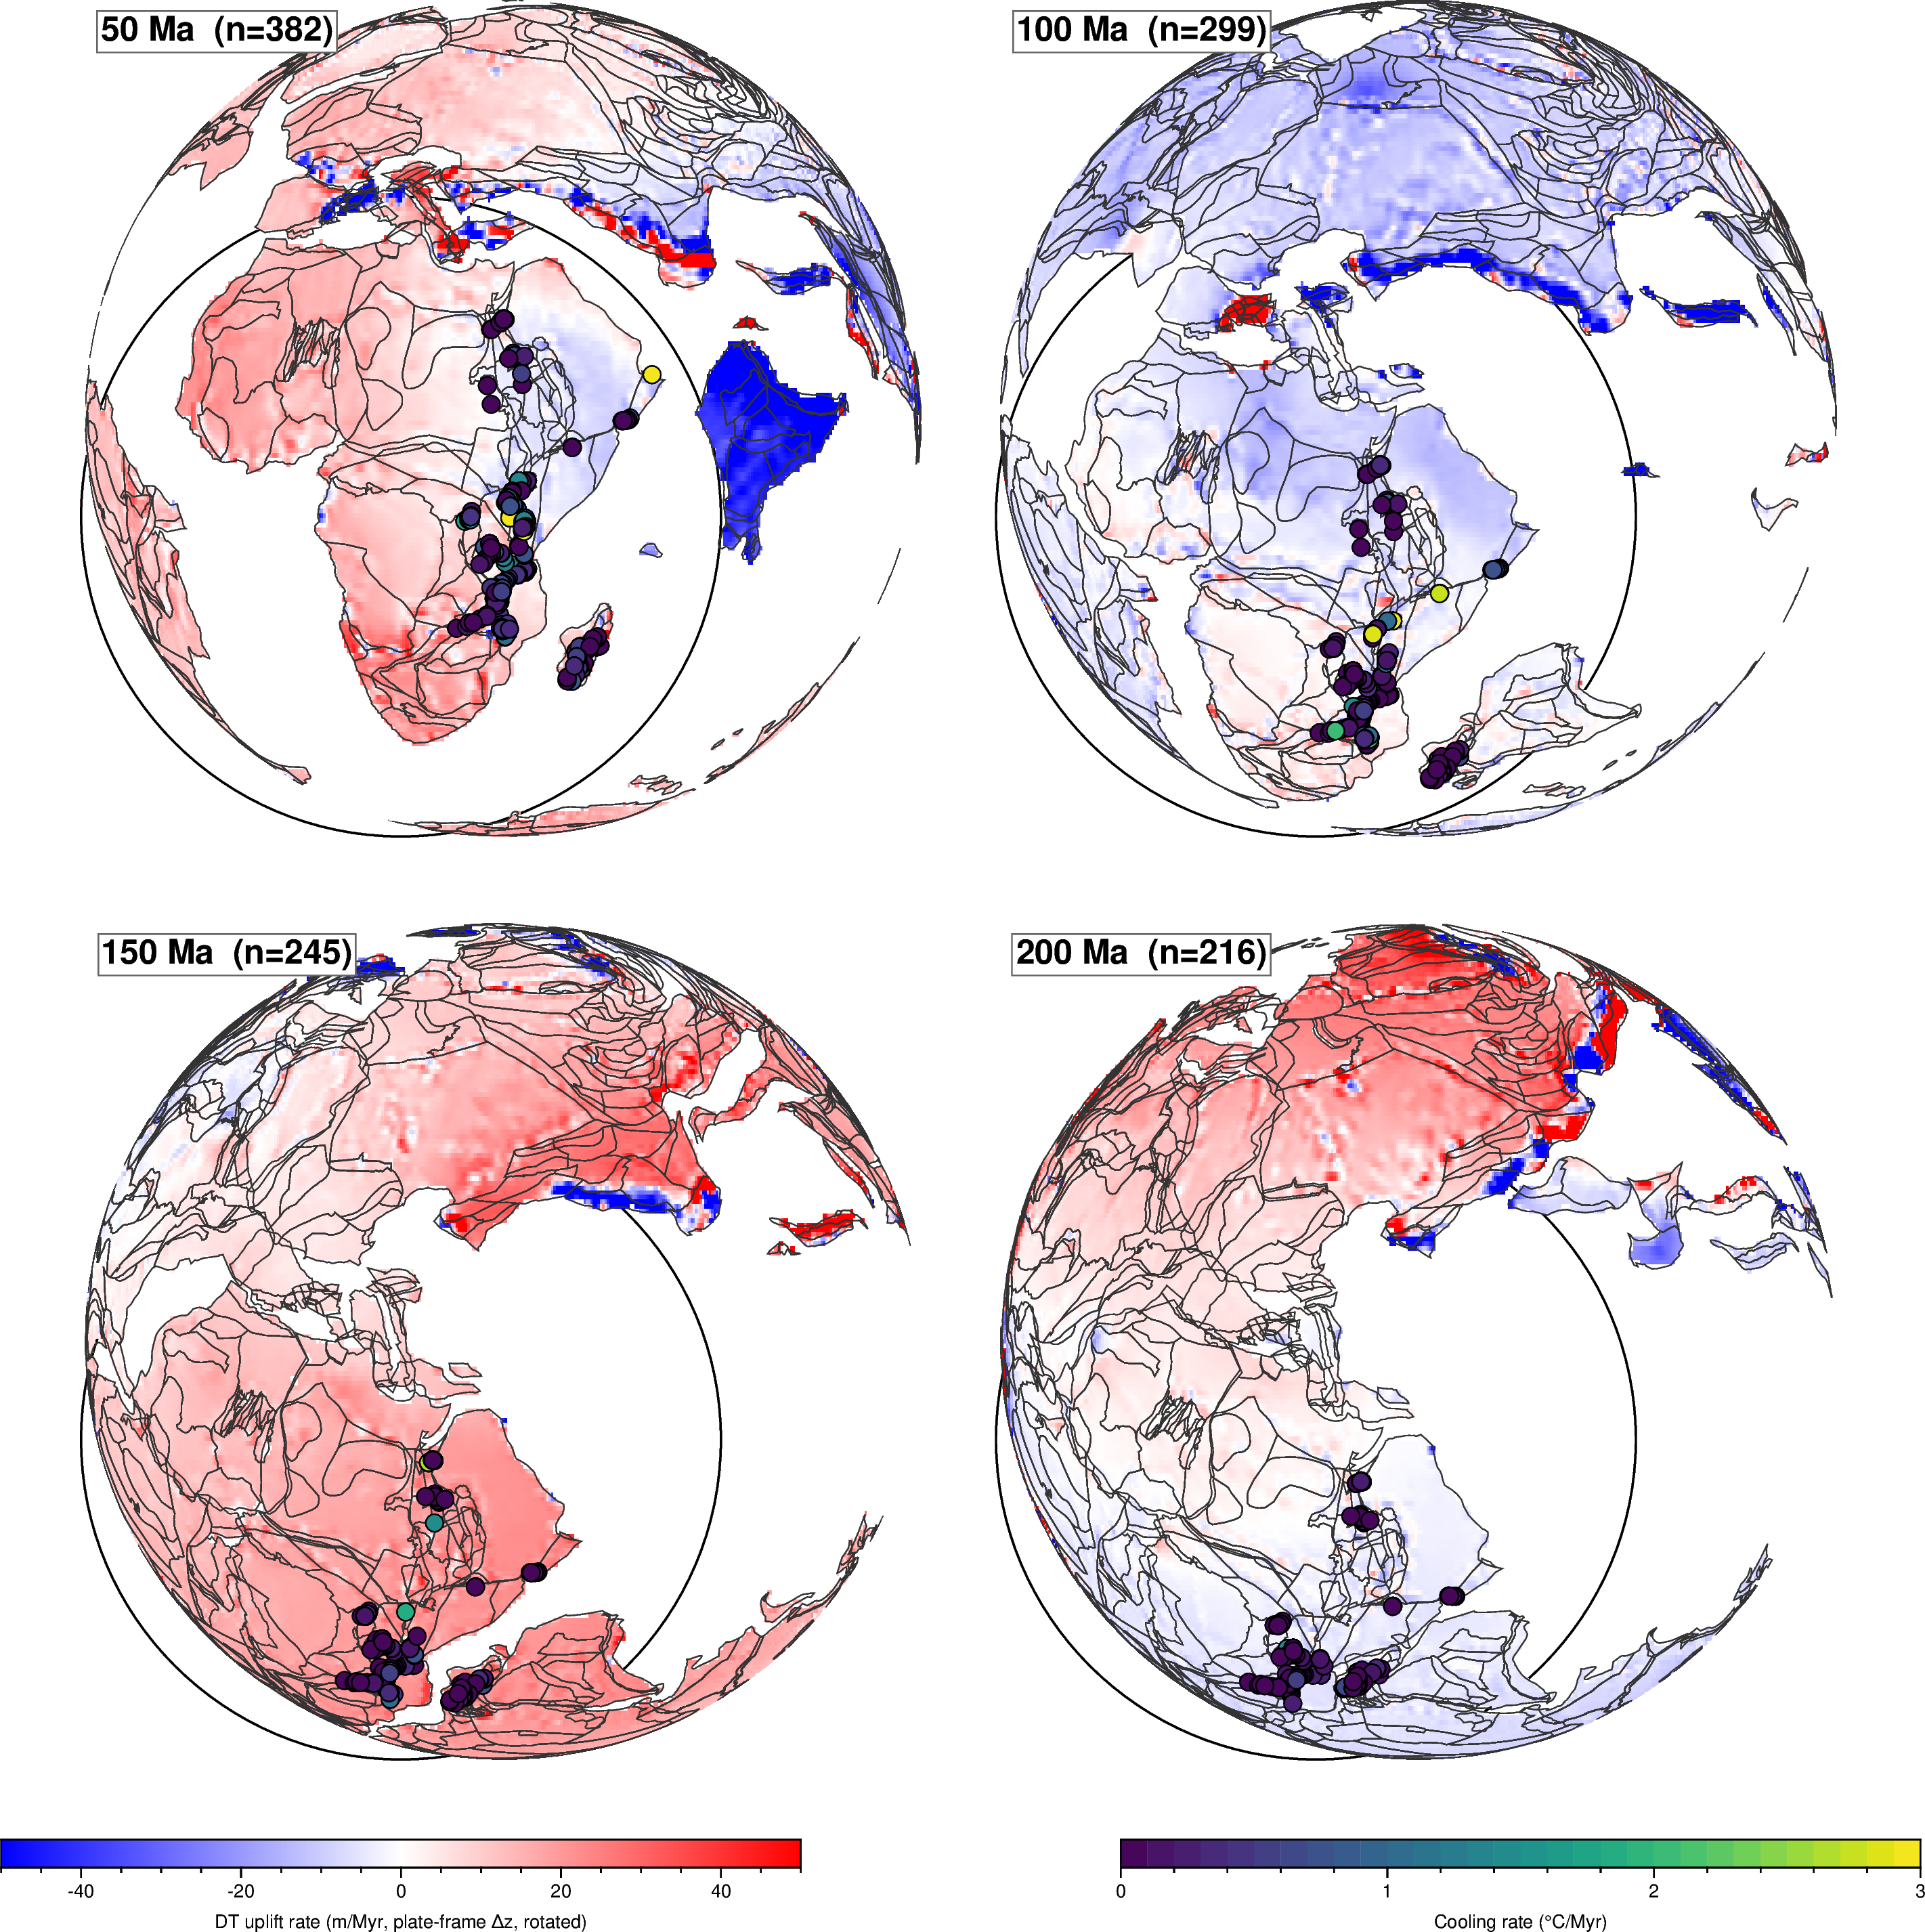

In [8]:
fig_dt = pygmt.Figure()
n_ages = len(DYNTOPO_SNAPSHOT_AGES)
n_cols = 2     # 2×2 grid for 4 snapshot ages
n_rows = (n_ages + n_cols - 1) // n_cols

# Africa-centred orthographic projection for every panel
DYNTOPO_PROJ = "G25/5/8c"

with fig_dt.subplot(nrows=n_rows, ncols=n_cols, figsize=("22c", "22c"),
                    sharex="b", sharey="l", margins=["0.3c", "0.4c"]):
    for idx, age in enumerate(DYNTOPO_SNAPSHOT_AGES):
        with fig_dt.set_panel(panel=idx):
            try:
                # Compute Δz in plate frame, then rotate to mantle/M21 NNR
                # frame for display (T23 pattern; required by the no-mantle-
                # frame-differencing rule).
                upl_rate = uplift_rate_for_display(float(age))
                upl_rate.gmt.registration = 0; upl_rate.gmt.gtype = 1
                fig_dt.basemap(region="d", projection=DYNTOPO_PROJ, frame=["af"])
                pygmt.makecpt(cmap="polar", series=list(UPLIFT_RANGE_M_PER_MYR),
                               continuous=True, background="o")
                fig_dt.grdimage(grid=upl_rate, cmap=True, nan_transparent=True)
                # M21 NNR continental outlines at this age
                gplot_m = gplately.PlotTopologies(
                    plate_reconstruction=recon_m21,
                    coastlines=None, continents=m21_continents_fc, COBs=None,
                    time=float(age), plot_engine=gplately.PygmtPlotEngine())
                try:
                    fig_dt.plot(data=gplot_m.get_continents(), pen="0.4p,gray20")
                except Exception:
                    pass
                # Samples at this age — reconstructed via M21 NNR for display
                samp = sample_dyntopo_at_age(float(age), hist)
                if not samp.empty:
                    samp_plot = samp.dropna(subset=["rlon_m21", "rlat_m21"])
                    if not samp_plot.empty:
                        pygmt.makecpt(cmap="viridis", series=[*COOLING_CPT_RANGE, 0.1],
                                       background="o")
                        fig_dt.plot(x=samp_plot["rlon_m21"], y=samp_plot["rlat_m21"],
                                     fill=samp_plot["cooling_rate"], cmap=True,
                                     style="c0.22c", pen="0.4p,black")
                # In-frame time stamp
                fig_dt.text(text=f"{int(age)} Ma  (n={len(samp)})",
                             position="TL", offset="0.2c/-0.2c", justify="TL",
                             font="12p,Helvetica-Bold,black",
                             fill="white", pen="0.5p,gray40")
            except FileNotFoundError as e:
                print(f"  skip {age} Ma: {e}")

# Two shared colour bars below the panel grid
pygmt.makecpt(cmap="polar", series=list(UPLIFT_RANGE_M_PER_MYR), continuous=True, background="o")
fig_dt.colorbar(cmap=True, position="JBC+w10c/0.35c+h+o-7c/1.0c",
                 frame=["xa20f5+lDT uplift rate (m/Myr, plate-frame Δz, rotated)"])
pygmt.makecpt(cmap="viridis", series=[*COOLING_CPT_RANGE, 0.1], background="o")
fig_dt.colorbar(cmap=True, position="JBC+w10c/0.35c+h+o7c/1.0c",
                 frame=["xa1f0.2+lCooling rate (@.C/Myr)"])
fig_dt.show(width=1200)


### What these globes tell you

The four panels (50, 100, 150, 200 Ma) show the long-wavelength dynamic-topography uplift rate at the AARS sample positions through the Mesozoic. **Don't expect to see the Afar / East-African plume here** — `gld428` suppresses thermal plumes by design (see the §5 disclaimer), so any plume-driven uplift over the late-Cretaceous / Cenozoic history of the AARS will NOT appear in these maps. What you should see instead are:

- **Subsidence (blue) bands along formerly-active margins** — the Tethyan margin to the north of Africa-Arabia, the proto-Indian Ocean margin to the east, the South Atlantic margin to the west — these track slab-pull-induced downwelling as Tethys / Atlantic subducted under the surrounding plates.
- **Broader patches of mantle-return-flow uplift (red)** — these are the *passive* uplift signals driven by the same subduction systems through the long-wavelength return flow, typically positioned over continental interiors away from active margins.
- **Slowly-evolving rather than rapidly-varying patterns** — the 50-Myr cadence captures the long-term DT background, not the rapid plume-head events.

Compare the AARS cooling-rate dots overlaid on each panel against these long-wavelength DT signatures. *Strong agreement* would suggest cooling histories were modulated by long-wavelength mantle flow; *weak or no agreement* would mean the cooling signal is dominated by other drivers (active plumes that `gld428` doesn't model, rift-flank tectonics, climate-modulated erosion).

## 7. Cross-variable correlations — cooling rate vs DT uplift rate, time-series

Same pipeline as the earlier convergence-rate analysis, but with `gld428` uplift rate replacing the convergence rate. For each age slice with at least three AARS samples actively cooling, we sample `gld428` at the M21 NNR-reconstructed sample positions and compute Pearson `r(cooling, uplift_rate)`. A positive trend across many ages would support the plume-driven-exhumation hypothesis.

In [9]:
# Build per-age master tables (cooling rate + dyntopo uplift rate at M21 NNR pos)
DYNTOPO_MASTER_DIR = Path("data/thermochronology_afro_arabia/dyntopo_master")
DYNTOPO_MASTER_DIR.mkdir(parents=True, exist_ok=True)

def dyntopo_master_path(age): return DYNTOPO_MASTER_DIR / f"dyntopo_master_{int(age):03d}Ma.parquet"

# Only build for ages within gld428 coverage AND covered by the AARS dataset
DYNTOPO_AGES      = [a for a in AGES_MA if a + DYNTOPO_STEP_MYR <= 250]
# Restricted age list for the cooling-vs-uplift CORRELATION (§7 below):
# omit post-50 Ma per the plume-suppression caveat (§5).
DYNTOPO_AGES_CORR = [a for a in DYNTOPO_AGES if a >= 50]
n_built = n_cached = n_skipped = 0
for age in DYNTOPO_AGES:
    p = dyntopo_master_path(age)
    if p.exists(): n_cached += 1; continue
    try:
        df = sample_dyntopo_at_age(float(age), hist)
        if df is None or df.empty: n_skipped += 1; continue
        df.to_parquet(p); n_built += 1
    except FileNotFoundError:
        n_skipped += 1
print(f"  ✓ built {n_built} new parquet(s); {n_cached} cached; {n_skipped} skipped (no data)")


  ✓ built 0 new parquet(s); 47 cached; 0 skipped (no data)


### Time-series of cooling rate AND dyntopo uplift rate — N vs S AARS samples

Two stacked panels covering the full 0–250 Ma window:

- **Top — cooling rate**: derived directly from the AARS thermochronology and therefore unaffected by the `gld428` plume-suppression caveat; can be read across the entire age range.
- **Bottom — `gld428` uplift rate**: sampled at each AARS sample's present-day position (plate-frame attached). The 0–50 Ma interval is shaded grey to flag that `gld428` does not represent the Afar / East-African plume that dominates the post-50 Ma AARS uplift history; the median uplift-rate line in that shaded interval is the *long-wavelength subduction-coupled signal only* and should not be interpreted as the true uplift history of the AARS over the Cenozoic.

The samples split roughly evenly at the equator:

- **Northern sector (lat > 0°)** — Arabia, Ethiopia, Sudan, Egypt, Sinai (n ≈ 216 samples)
- **Southern sector (lat ≤ 0°)** — Kenya, Tanzania, Madagascar, Mozambique (n ≈ 209 samples)

Median ± inter-quartile-range bands per sector; faint background traces are individual sample trajectories. The downstream cooling-vs-uplift correlation (next cell) restricts itself to ≥ 50 Ma per the same caveat.

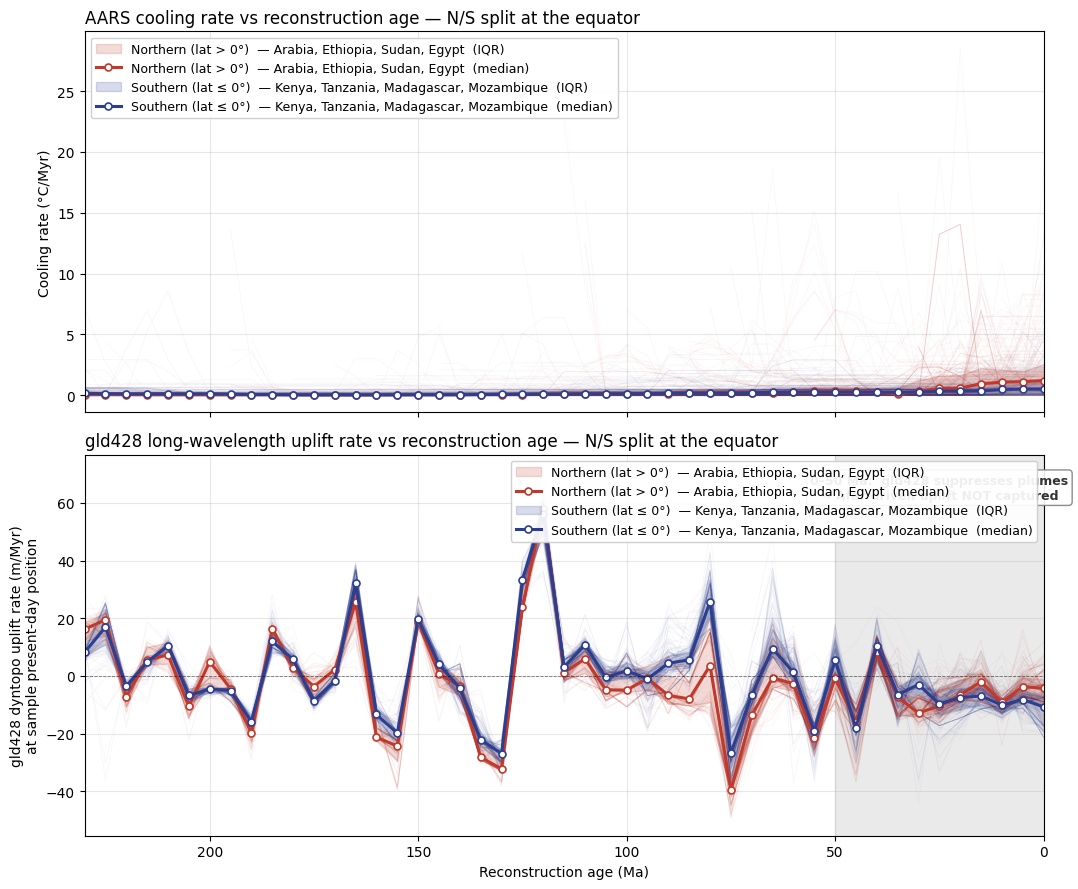


Per-sector median UPLIFT RATE (m/Myr) by age:
sector      N      S
age_Ma              
0.0     -4.29 -10.68
5.0     -3.66  -8.16
10.0    -9.18 -10.10
15.0    -2.00  -6.93
20.0    -6.47  -7.49
25.0   -10.41  -9.69
30.0   -12.77  -2.98
35.0    -7.34  -6.43
40.0     8.34  10.54
45.0   -15.76 -18.02
50.0    -0.81   5.57
55.0   -21.30 -19.03
60.0    -2.70   1.26
65.0    -0.59   9.47
70.0   -13.67  -6.59
75.0   -39.48 -26.77
80.0     3.62  25.74
85.0    -7.96   5.61
90.0    -6.70   4.41
95.0    -0.81  -0.96
100.0   -4.91   1.78
105.0   -4.76  -0.44
110.0    5.99  10.79
115.0    1.13   3.11
120.0   57.93  56.15
125.0   23.88  33.34
130.0  -32.18 -26.89
135.0  -28.17 -22.00
140.0   -3.40  -4.31
145.0    0.67   4.01
150.0   18.77  19.72
155.0  -24.29 -19.85
160.0  -21.20 -13.33
165.0   25.65  32.16
170.0    2.25  -1.70
175.0   -3.65  -8.60
180.0    2.83   5.78
185.0   16.34  11.99
190.0  -19.78 -15.84
195.0   -4.35  -5.03
200.0    4.96  -4.56
205.0  -10.47  -6.74
210.0    7.33  10.50
215.0   

In [10]:
# Pool master parquet files + split N vs S
NS_THRESHOLD_LAT = 0.0   # equator
frames = []
for a in DYNTOPO_AGES:
    p = dyntopo_master_path(a)
    if not p.exists(): continue
    df = pd.read_parquet(p)
    if "age_Ma" not in df.columns: df["age_Ma"] = float(a)
    frames.append(df)
ts_pool = pd.concat(frames, ignore_index=True)
ts_pool["sector"] = np.where(ts_pool["lat"] > NS_THRESHOLD_LAT, "N", "S")

# Per-age, per-sector median + IQR for BOTH metrics
def summarise(metric_col):
    return (ts_pool.dropna(subset=[metric_col])
                   .groupby(["age_Ma", "sector"])[metric_col]
                   .agg(median="median", q25=lambda s: s.quantile(0.25),
                        q75=lambda s: s.quantile(0.75), n="count").reset_index())
summ_cool = summarise("cooling_rate")
summ_upl  = summarise("uplift_rate_m_per_Myr")

sector_colors = {"N": "#c0392b", "S": "#2c3e90"}
sector_labels = {"N": "Northern (lat > 0°)  — Arabia, Ethiopia, Sudan, Egypt",
                 "S": "Southern (lat ≤ 0°)  — Kenya, Tanzania, Madagascar, Mozambique"}

fig, (ax_c, ax_u) = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

# --- top panel: COOLING RATE (full 0-250 Ma, no caution shading) -----------
for sname, g in ts_pool.dropna(subset=["cooling_rate"]).groupby("sample_name"):
    g = g.sort_values("age_Ma"); sec = g["sector"].iloc[0]
    ax_c.plot(g["age_Ma"], g["cooling_rate"], color=sector_colors[sec], alpha=0.04, lw=0.6)
for sec in ("N", "S"):
    sub = summ_cool[summ_cool["sector"] == sec].sort_values("age_Ma")
    ax_c.fill_between(sub["age_Ma"], sub["q25"], sub["q75"],
                       color=sector_colors[sec], alpha=0.18, label=f"{sector_labels[sec]}  (IQR)")
    ax_c.plot(sub["age_Ma"], sub["median"], color=sector_colors[sec],
              lw=2.2, marker="o", markersize=5, markerfacecolor="white",
              markeredgewidth=1.2, label=f"{sector_labels[sec]}  (median)")
ax_c.set_ylabel("Cooling rate (°C/Myr)")
ax_c.grid(alpha=0.3)
ax_c.set_title("AARS cooling rate vs reconstruction age — N/S split at the equator", loc="left")
ax_c.legend(loc="upper left", fontsize=9, framealpha=0.92, ncol=1)

# --- bottom panel: gld428 UPLIFT RATE (0-250 Ma, post-50 Ma shaded grey) ----
for sname, g in ts_pool.dropna(subset=["uplift_rate_m_per_Myr"]).groupby("sample_name"):
    g = g.sort_values("age_Ma"); sec = g["sector"].iloc[0]
    ax_u.plot(g["age_Ma"], g["uplift_rate_m_per_Myr"], color=sector_colors[sec], alpha=0.04, lw=0.6)
for sec in ("N", "S"):
    sub = summ_upl[summ_upl["sector"] == sec].sort_values("age_Ma")
    ax_u.fill_between(sub["age_Ma"], sub["q25"], sub["q75"],
                       color=sector_colors[sec], alpha=0.18, label=f"{sector_labels[sec]}  (IQR)")
    ax_u.plot(sub["age_Ma"], sub["median"], color=sector_colors[sec],
              lw=2.2, marker="o", markersize=5, markerfacecolor="white",
              markeredgewidth=1.2, label=f"{sector_labels[sec]}  (median)")
ax_u.axhline(0, color="black", lw=0.6, ls="--", alpha=0.5)
# Plume-suppression caution band for 0-50 Ma
ax_u.axvspan(0, 50, color="0.82", alpha=0.45, zorder=0)
ax_u.text(25, 0.95, "0–50 Ma:  gld428 suppresses plumes\n→ Afar-driven uplift NOT captured",
           transform=ax_u.get_xaxis_transform(), ha="center", va="top",
           fontsize=9, color="0.20", fontweight="bold",
           bbox=dict(facecolor="white", edgecolor="0.5", boxstyle="round,pad=0.3", alpha=0.9))
ax_u.set_ylabel("gld428 dyntopo uplift rate (m/Myr)\nat sample present-day position")
ax_u.set_xlabel("Reconstruction age (Ma)")
ax_u.grid(alpha=0.3)
ax_u.set_title("gld428 long-wavelength uplift rate vs reconstruction age — N/S split at the equator", loc="left")
ax_u.legend(loc="upper right", fontsize=9, framealpha=0.92, ncol=1)

# Geological convention: older to the right
all_ages = [a for a in DYNTOPO_AGES]
for a in (ax_c, ax_u):
    a.set_xlim(max(all_ages), min(all_ages))
fig.tight_layout(); plt.show()

# Print summary stats
print("\nPer-sector median UPLIFT RATE (m/Myr) by age:")
piv = summ_upl.pivot_table(index="age_Ma", columns="sector", values="median").round(2)
print(piv.to_string())


  pooled: 9,905 (sample, age) pairs across 37 ages


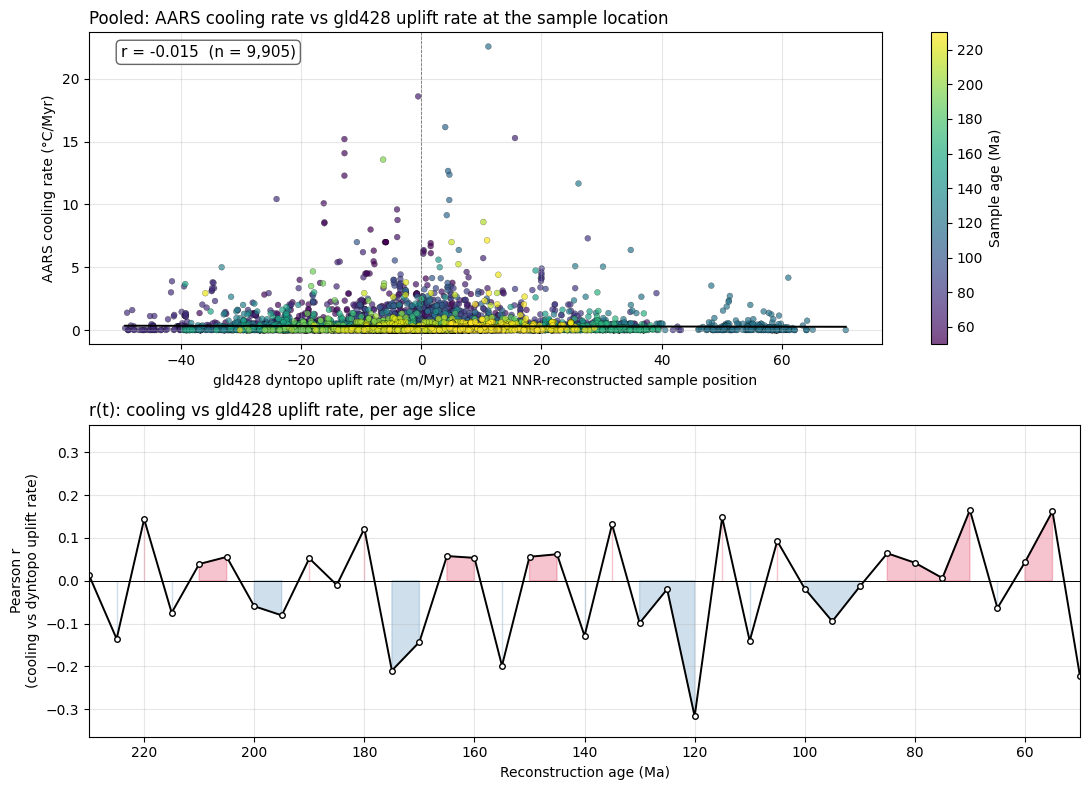

In [11]:
# Pool + Pearson r per age + plot
frames = [pd.read_parquet(dyntopo_master_path(a)) for a in DYNTOPO_AGES_CORR if dyntopo_master_path(a).exists()]
pool = pd.concat(frames, ignore_index=True)
# Sanity: drop NaN uplift-rate rows (samples that landed in NaN cells of the gld428 grid)
pool = pool.dropna(subset=["uplift_rate_m_per_Myr"]).copy()
print(f"  pooled: {len(pool):,} (sample, age) pairs across "
      f"{pool['age_Ma'].nunique() if 'age_Ma' in pool.columns else 'n'} ages")
# age_Ma column for grouping
if "age_Ma" not in pool.columns:
    # Reconstruct age_Ma column from parquet filenames
    rows = []
    for a in DYNTOPO_AGES_CORR:
        p = dyntopo_master_path(a)
        if not p.exists(): continue
        df = pd.read_parquet(p); df["age_Ma"] = float(a); rows.append(df)
    pool = pd.concat(rows, ignore_index=True).dropna(subset=["uplift_rate_m_per_Myr"])

def pearson_r(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3: return np.nan, int(m.sum())
    return float(np.corrcoef(x[m], y[m])[0, 1]), int(m.sum())

r_rows = []
for age, sub in pool.groupby("age_Ma"):
    r, n = pearson_r(sub["uplift_rate_m_per_Myr"].to_numpy(float),
                      sub["cooling_rate"].to_numpy(float))
    r_rows.append({"age_Ma": age, "r_cool_vs_uplift": r, "n": n})
r_by_age = pd.DataFrame(r_rows).sort_values("age_Ma")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8))
df = pool.dropna(subset=["uplift_rate_m_per_Myr", "cooling_rate"])
age_norm = Normalize(min(DYNTOPO_AGES_CORR), max(DYNTOPO_AGES_CORR))
sc = ax1.scatter(df["uplift_rate_m_per_Myr"], df["cooling_rate"],
                  c=df["age_Ma"], cmap="viridis", norm=age_norm,
                  s=18, edgecolor="black", linewidth=0.2, alpha=0.7)
if len(df) > 1:
    slope, intercept = np.polyfit(df["uplift_rate_m_per_Myr"], df["cooling_rate"], 1)
    xl = np.linspace(df["uplift_rate_m_per_Myr"].min(), df["uplift_rate_m_per_Myr"].max(), 100)
    ax1.plot(xl, slope*xl + intercept, color="black", lw=1.4)
r_all, n_all = pearson_r(df["uplift_rate_m_per_Myr"].values, df["cooling_rate"].values)
ax1.text(0.04, 0.96, f"r = {r_all:+.3f}  (n = {n_all:,})",
         transform=ax1.transAxes, va="top", ha="left", fontsize=11,
         bbox=dict(facecolor="white", edgecolor="0.40", boxstyle="round,pad=0.3"))
ax1.axvline(0, color="black", lw=0.6, ls="--", alpha=0.5)
ax1.set_xlabel("gld428 dyntopo uplift rate (m/Myr) at M21 NNR-reconstructed sample position")
ax1.set_ylabel("AARS cooling rate (°C/Myr)")
ax1.grid(alpha=0.3)
ax1.set_title("Pooled: AARS cooling rate vs gld428 uplift rate at the sample location", loc="left")
plt.colorbar(sc, ax=ax1, label="Sample age (Ma)")

valid = r_by_age.dropna(subset=["r_cool_vs_uplift"])
ax2.axhline(0, color="black", lw=0.7)
ax2.fill_between(valid["age_Ma"], valid["r_cool_vs_uplift"], 0,
                  where=(valid["r_cool_vs_uplift"] > 0), alpha=0.25, color="crimson")
ax2.fill_between(valid["age_Ma"], valid["r_cool_vs_uplift"], 0,
                  where=(valid["r_cool_vs_uplift"] < 0), alpha=0.25, color="steelblue")
ax2.plot(valid["age_Ma"], valid["r_cool_vs_uplift"], color="black", lw=1.4,
         marker="o", markersize=4, markerfacecolor="white")
ax2.set_ylabel("Pearson r\n(cooling vs dyntopo uplift rate)")
_r_abs = max(0.2, max(abs(valid["r_cool_vs_uplift"].min()),
                       abs(valid["r_cool_vs_uplift"].max())))
ax2.set_ylim(-_r_abs * 1.15, _r_abs * 1.15)
ax2.set_xlim(max(DYNTOPO_AGES_CORR), min(DYNTOPO_AGES_CORR))
ax2.set_xlabel("Reconstruction age (Ma)")
ax2.grid(alpha=0.3)
ax2.set_title("r(t): cooling vs gld428 uplift rate, per age slice", loc="left")
fig.tight_layout(); plt.show()


### Interpreting the r(t) trajectory

A persistently *positive* `r(t)` (above the zero line, red shading) across many snapshot ages would be the cleanest statistical signature that AARS samples cool faster where mantle flow is lifting the surface — i.e., plume-driven exhumation. A flat-to-zero `r(t)` would suggest that whatever drives AARS cooling rates is decoupled from `gld428` uplift rate at the sample positions (other candidates: erosion driven by climate, rift-flank tectonic uplift, or a real plume signal that `gld428` doesn't resolve because of its model assumptions). Negative `r(t)` would be unexpected and worth digging into.

**Important caveats**:
- `gld428` is one model among several; the African plume signal varies between geodynamic models, and the polarity / amplitude of the basal heat-flow / phase-buoyancy implementation can change the inferred uplift.
- The reconstruction uses M21 NNR (the frame the model was run in) — different from the Z22 frame used in §1-§4 of this notebook. This is the correct plate-model-match (see CLAUDE.md), but you cannot directly compare the *spatial* sample positions between the two reconstructions.
- Mantle-frame differencing of `gld428` (rather than the rigorous plate-frame-then-rotate approach in T23) introduces a small plate-motion-through-DT-field error; for slow-moving Africa this is small compared with the DT variations themselves but is non-zero.

## Extend this

### Maps at other snapshot ages — getting more SW PaleoDEM grids

The bundled `data/paleotopo_scotese/corrected_SW/` directory ships **16 ages** (0, 25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 300, 350, 400, 450, 500 Ma) — every age likely to be picked as `RECONSTRUCTION_TIME` in the current suite. For full 5-Myr cadence (109 NCs, 0–540 Ma), two sources:

- **Geochemistry-corrected SW PaleoDEMs** (the ones bundled here) — Zhou, Müller & Farahbakhsh (in review, *ESR*); upstream repository is `https://github.com/EarthByte/paleotopo-data-assimilation`. Clone it locally and either drop a symlink at `external/Paleotopo_data_assimilation/` (the resolver in cell 4 will find it) or extend the `PALEODEM_DIR_CANDIDATES` list.
- **Original (uncorrected) Scotese & Wright 2018 PaleoDEMs** — 88 NCs at 5-Myr cadence direct from EarthByte: https://www.earthbyte.org/paleodem-resource-scotese-and-wright-2018/. Different filename convention (`Map##_PALEOMAP_1deg_<EpochName>_<age>Ma.nc`) so if you go this route, swap the paleotopo file-glob in cell 8 (`*_corrected_SW.nc`) for `*Ma.nc` and adjust the age-extraction regex.


- **Dynamic-topography overlay (T48 template).** Dynamic topography may be regionally important for the AARS — Afar plume uplift in particular — but is generally less of a *driver* of exhumation than rift-flank tectonics. T48 contains the full plate-frame ΔDT/Δt pipeline (Braz et al. 2021 gmcm9, rotated to mantle frame via T23's helper). Mirror that block here: copy the *Layer B* + *5-snapshot loop* cells from T48, repoint the sample dots at the AARS `samples_now`, and add Pearson r vs age in §6 with `dyn_topo_m` / `delta_dt_m_per_Myr` as additional environmental variables. The same hook works unchanged for T52 (S-C Andes).
- **Rift-distance + rift-opening-rate as an environmental variable.** For passive-margin / rift systems like the AARS, the more physically relevant kinematic forcing isn't subduction convergence — it's distance to the nearest active rift and the rift's opening rate. Add a function `nearest_rift_opening_rate(sample_lons, sample_lats, recon, age)` that uses `gplately.PlateReconstruction.tessellate_mid_ocean_ridges()` (analogue of the subduction-zone tessellation) and a similar KDTree query. Re-do the §6 r(t) analysis with rift-opening rate instead of convergence rate.
- **Fault-proximity test (T49 template).** The GEM Global Active Faults Database covers Afro-Arabia (the East African Rift faults, Atlas Mts, Bitlis-Zagros, etc.). Drop GEM into `data/thermochronology/Faults_GEM_AfroArabia/` (subset the bundled GEM by lat/lon to the AARS box) and copy T49's §7 fault-proximity block: which faults sit within 25 km of fast-cooling AARS samples?
- **Compare against the Boone et al. (2025) Sci. Data paper's own analyses.** The paper makes specific claims about which AARS sub-regions cool when and why (Phanerozoic basin inversion, late-Paleogene EARS initiation, Atlas Mts uplift acceleration). Use the `Region` / `Sub-Region` columns to split this analysis by sub-region and reproduce / interrogate those claims.
- **Sibling notebook for South-Central Andes (T52).** T52 uses the Howlett et al. (2025) Zenodo deposit (DOI 10.5281/zenodo.11152585) to apply this same workflow to the Andean Frontal Cordillera (DOI 10.2475/06.2016.01). Both are convergence-dominated orogens — the same §5 + §6 cooling × convergence-rate analysis here will be much more directly applicable, and a strong positive r is expected.

## References

- Boone, S.C., Glorie, S., Sutherland, R., Garber, J.M., Beucher, R., Kohn, B.P., Kohlmann, F., Theile, M., Noble, W., Danišík, M., McMillan, M. & Nixon, A. (2025). Phanerozoic thermochronology record of Afro-Arabia through space and time. *Scientific Data* 12, 472. https://doi.org/10.1038/s41597-025-04767-6
- Boone, S.C. et al. (2024). Afro-Arabian low-temperature thermochronology database. *EarthBank Platform* [Dataset]. https://doi.org/10.58024/AGUM97FC4439
- Boone, S.C., Kohlmann, F., Noble, W., Theile, M., Beucher, R., Kohn, B., Glorie, S., Danišík, M., Zhou, R., McMillan, M. & Nixon, A. (2023). A geospatial platform for the tectonic interpretation of low-temperature thermochronology Big Data. *Scientific Reports* 13(1), 8581. https://doi.org/10.1038/s41598-023-35776-3
- Boone, S.C., Glorie, S., Zahirovic, S., Nixon, A., Meeuws, F. & Kohlmann, F. (2025). Deciphering mantle, tectonic and climatic drivers of exhumation. *Communications Earth & Environment* 6, 1015. https://doi.org/10.1038/s43247-025-03005-6 — companion ThermoPlates Central Asia paper; T47 / T48 / T49 / T50 are the suite's Python re-implementations of that workflow.
- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Müller, R.D. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9, 371–383. https://doi.org/10.1002/gdj3.146
- Mather, B.R., Müller, R.D., Zahirovic, S., Cannon, J., Chin, M., Ilano, L., Wright, N.M., Alfonso, C., Williams, S., Tetley, M. & Merdith, A. (2024). Deep time spatio-temporal data analysis using GPlately. *Geoscience Data Journal* 11(1), 3–10. https://doi.org/10.1002/gdj3.185
- Tian, D., Uieda, L., Leong, W.J., et al. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.13679420
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems* 20(11), 5556–5564. https://doi.org/10.1029/2019GC008515